# spike_discrim — minimal process notebook

This notebook is a **minimum-viable, high-level tour** of the repository.

It is designed for a technically fluent first-time reader who wants to:

1. see the **canonical data objects** used by the repo,
2. inspect a few **real and synthetic waveform snippets**,
3. read the **latest benchmark outputs** as tables,
4. understand the **smallest set of commands** needed to run the project,
5. do all of this with **guard rails** so nothing heavy runs unless explicitly enabled.

## Philosophy

- **Minimal**: only a few cells, each doing one high-level thing.
- **Transparent**: objects are loaded directly from their saved files.
- **Safe by default**: heavy actions are disabled behind booleans.
- **Interpretable**: outputs are tables, compact summaries, and waveform previews.

If you only run the notebook top-to-bottom without changing any flags, it should behave as a **read-only orientation + inspection notebook**.

In [10]:
from __future__ import annotations

import json
import random
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ---- safety switches: keep these False for a read-only tour ----
RUN_PIPELINE = True
CALL_LOCAL_API = True
RUN_REAL_EVAL = True
N_PREVIEW = 12
RANDOM_SEED = 7

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ---- repo paths ----
REPO = Path.cwd()
if not (REPO / 'data').exists() and (REPO.parent / 'data').exists():
    REPO = REPO.parent

DATA = REPO / 'data'
SYNTH = DATA / 'synthetic'
RESULTS = DATA / 'results'
DOCS = REPO / 'docs'

assert DATA.exists(), f"Could not find data/ under {REPO}"

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)


def latest_run_dir(results_dir: Path) -> Path | None:
    runs = sorted([p for p in results_dir.iterdir() if p.is_dir() and p.name[:8].isdigit()]) if results_dir.exists() else []
    return runs[-1] if runs else None


def load_npz_dict(path: Path) -> dict:
    with np.load(path, allow_pickle=False) as bundle:
        return {k: bundle[k] for k in bundle.files}


def summarize_npz(path: Path) -> pd.DataFrame:
    obj = load_npz_dict(path)
    rows = []
    for key, value in obj.items():
        rows.append({
            'file': path.name,
            'array': key,
            'shape': tuple(value.shape),
            'dtype': str(value.dtype),
            'min': float(np.min(value)) if np.issubdtype(value.dtype, np.number) else None,
            'max': float(np.max(value)) if np.issubdtype(value.dtype, np.number) else None,
        })
    return pd.DataFrame(rows)


def sample_rows(n_total: int, n: int) -> np.ndarray:
    if n_total == 0:
        return np.array([], dtype=int)
    n = min(n, n_total)
    return np.random.choice(n_total, size=n, replace=False)


def plot_examples(ax, waveforms: np.ndarray, title: str, color: str, n: int = 6):
    idx = sample_rows(len(waveforms), n)
    if len(idx) == 0:
        ax.set_title(f"{title} (none)")
        ax.axis('off')
        return
    t = np.arange(waveforms.shape[1])
    for i in idx:
        ax.plot(t, waveforms[i], color=color, alpha=0.65, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel('sample index')
    ax.set_ylabel('uV')
    ax.axhline(0, color='black', lw=0.75, alpha=0.3)
    ax.grid(alpha=0.2)


LATEST_RUN = latest_run_dir(RESULTS)
print(f"Repo root     : {REPO}")
print(f"Latest run    : {LATEST_RUN.name if LATEST_RUN else 'none found'}")
print(f"Read-only mode: {not any([RUN_PIPELINE, CALL_LOCAL_API, RUN_REAL_EVAL])}")

Repo root     : /Users/marco/Cursor_Folder/Cursor_Codespace/spike_discrim
Latest run    : 20260405_153115
Read-only mode: False


## 1. Smallest useful entry points

The repo has a few **high-level commands** that matter most.

The table below is meant to be the shortest operational summary:

- one command to run the benchmark pipeline,
- one command to start the API,
- one notebook for OSort extraction,
- one notebook for this high-level inspection pass.

Heavy actions remain disabled unless you flip the booleans in the setup cell.

In [11]:
entry_points = pd.DataFrame([
    {
        'task': 'Run full benchmark pipeline',
        'command': f"{sys.executable} scripts/run_benchmark.py --tier 3",
        'writes_to': 'data/results/<timestamp>/',
        'why_it_matters': 'Creates the canonical feature, ranking, and WeightBank outputs.'
    },
    {
        'task': 'Run pipeline on real curated snippets',
        'command': f"{sys.executable} scripts/run_benchmark.py --tier 3 --waveforms-file data/synthetic/waveforms_real.npz",
        'writes_to': 'data/results/<timestamp>/',
        'why_it_matters': 'Tests whether the pipeline behaves similarly on real OSort-curated waveforms.'
    },
    {
        'task': 'Start local API',
        'command': f"{sys.executable} -m uvicorn api.main:app --port 8099 --reload",
        'writes_to': 'runtime only',
        'why_it_matters': 'Lets you inspect runs and real-data evaluation from a browser or agent.'
    },
    {
        'task': 'Inspect OSort extraction notebook',
        'command': 'notebooks/osort_file_extraction.ipynb',
        'writes_to': 'data/synthetic/waveforms_real.npz + metadata',
        'why_it_matters': 'Builds the real labelled snippet dataset from curated MATLAB files.'
    },
    {
        'task': 'Inspect this notebook',
        'command': 'notebooks/repo_process_overview.ipynb',
        'writes_to': 'read-only unless flags are changed',
        'why_it_matters': 'Fast orientation with previews of the main data objects.'
    },
])

display(entry_points)

if RUN_PIPELINE:
    cmd = [sys.executable, 'scripts/run_benchmark.py', '--tier', '3']
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, cwd=REPO, check=True)
else:
    print('Pipeline execution skipped. Set RUN_PIPELINE = True to enable.')

,task,command,writes_to,why_it_matters
0,Run full benchmark pipeline,/Users/marco/Cursor_Folder/Cursor_Codespace/sp...,data/results/<timestamp>/,"Creates the canonical feature, ranking, and We..."
1,Run pipeline on real curated snippets,/Users/marco/Cursor_Folder/Cursor_Codespace/sp...,data/results/<timestamp>/,Tests whether the pipeline behaves similarly o...
2,Start local API,/Users/marco/Cursor_Folder/Cursor_Codespace/sp...,runtime only,Lets you inspect runs and real-data evaluation...
3,Inspect OSort extraction notebook,notebooks/osort_file_extraction.ipynb,data/synthetic/waveforms_real.npz + metadata,Builds the real labelled snippet dataset from ...
4,Inspect this notebook,notebooks/repo_process_overview.ipynb,read-only unless flags are changed,Fast orientation with previews of the main dat...


Running: /Users/marco/Cursor_Folder/Cursor_Codespace/spike_discrim/.venv/bin/python scripts/run_benchmark.py --tier 3
spike_discrim — Feature Benchmarking Pipeline
  Run dir    : data/results/20260405_181133
  Data dir   : data/synthetic
  Feature tier: 3
  Waveforms  : 1200 snippets × 64 samples
  Spikes     : 900  Noise: 300

[1/5] Profiling Tier 1/2 feature kernels...
ProfileResult(amplitude): 1200 snippets × 64 samples | wall=0.08 ms | 15,278,644 snippets/s | static_arith=0 ops/sample
ProfileResult(first_derivative): 1200 snippets × 64 samples | wall=0.05 ms | 24,080,429 snippets/s | static_arith=1 ops/sample
ProfileResult(second_derivative): 1200 snippets × 64 samples | wall=0.08 ms | 14,976,599 snippets/s | static_arith=3 ops/sample
ProfileResult(absolute_window_sum): 1200 snippets × 64 samples | wall=0.07 ms | 17,486,339 snippets/s | static_arith=1 ops/sample
ProfileResult(short_window_energy): 1200 snippets × 64 samples | wall=0.11 ms | 10,662,686 snippets/s | static_arith=2 op

## 2. Canonical data objects

The project is easiest to understand if you start from the **saved objects on disk**.

This section inspects the main objects directly:

- synthetic waveform bundle,
- synthetic label table,
- real curated waveform bundle,
- real metadata table,
- latest run directory.

The goal is to make each object legible before you care about any model.

In [5]:
synth_npz_path = SYNTH / 'waveforms.npz'
real_root = REPO / 'data' / 'real_units'
real_npz_path = real_root / 'waveforms_real.npz'
labels_path = SYNTH / 'labels.parquet'
real_meta_path = real_root / 'waveforms_real_meta.csv'

inventory = pd.DataFrame([
    {'path': str(synth_npz_path.relative_to(REPO)), 'exists': synth_npz_path.exists(), 'kind': 'synthetic snippets bundle'},
    {'path': str(labels_path.relative_to(REPO)), 'exists': labels_path.exists(), 'kind': 'synthetic labels table'},
    {'path': str(real_npz_path.relative_to(REPO)), 'exists': real_npz_path.exists(), 'kind': 'real curated snippets bundle'},
    {'path': str(real_meta_path.relative_to(REPO)), 'exists': real_meta_path.exists(), 'kind': 'real provenance / identity table'},
    {'path': str(LATEST_RUN.relative_to(REPO)) if LATEST_RUN else 'data/results/<none>', 'exists': LATEST_RUN is not None, 'kind': 'latest benchmark run'},
])

display(inventory)

objects = []
if synth_npz_path.exists():
    objects.append(summarize_npz(synth_npz_path))
if real_npz_path.exists():
    objects.append(summarize_npz(real_npz_path))

if objects:
    display(pd.concat(objects, ignore_index=True))

labels_df = pd.read_parquet(labels_path) if labels_path.exists() else pd.DataFrame()
real_meta = pd.read_csv(real_meta_path) if real_meta_path.exists() else pd.DataFrame()

if not labels_df.empty:
    display(Markdown('### Synthetic label table — first rows'))
    display(labels_df.head(8))

if not real_meta.empty:
    display(Markdown('### Real metadata table — first rows'))
    display(real_meta.head(8))

,path,exists,kind
0,data/synthetic/waveforms.npz,True,synthetic snippets bundle
1,data/synthetic/labels.parquet,True,synthetic labels table
2,data/synthetic/waveforms_real.npz,True,real curated snippets bundle
3,data/synthetic/waveforms_real_meta.csv,True,real provenance / identity table
4,data/results/20260405_153115,True,latest benchmark run


,file,array,shape,dtype,min,max
0,waveforms.npz,waveforms,"(1200, 64)",float32,-218.078491,224.573044
1,waveforms.npz,class_labels,"(1200,)",int32,0.000000,1.000000
2,waveforms.npz,unit_ids,"(1200,)",int32,0.000000,3.000000
3,waveforms_real.npz,waveforms,"(96006, 64)",float32,-1399.171387,1276.668701
4,waveforms_real.npz,class_labels,"(96006,)",int32,0.000000,1.000000
5,waveforms_real.npz,unit_ids,"(96006,)",int32,0.000000,10.000000


### Synthetic label table — first rows

,snippet_id,unit_id,class_label,noise_std,source,tau_rise,tau_fall,amp_neg,amp_pos,delay_pos,width_pos,amp_ahp,delay_ahp,amp_pre,cell_type,noise_type,amplitude
0,627,3,1,5.796802,procedural_spike,3.831877,11.255269,-78.618441,45.791610,11.0,7.240841,12.736282,30.0,9.251848,2.0,None,NaN
1,853,3,1,6.381201,procedural_spike,3.831877,11.255269,-78.618441,45.791610,11.0,7.240841,12.736282,30.0,9.251848,2.0,None,NaN
2,834,3,1,3.677915,procedural_spike,3.831877,11.255269,-78.618441,45.791610,11.0,7.240841,12.736282,30.0,9.251848,2.0,None,NaN
3,61,1,1,7.292712,procedural_spike,3.160934,8.755514,-107.070104,60.921041,9.0,7.926867,8.327978,20.0,6.716386,0.0,None,NaN
4,121,1,1,6.152641,procedural_spike,3.160934,8.755514,-107.070104,60.921041,9.0,7.926867,8.327978,20.0,6.716386,0.0,None,NaN
5,1128,0,0,NaN,noise_irregular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,irregular,99.680222
6,12,1,1,6.776208,procedural_spike,3.160934,8.755514,-107.070104,60.921041,9.0,7.926867,8.327978,20.0,6.716386,0.0,None,NaN
7,1119,0,0,NaN,noise_clipped,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,clipped,51.809109


### Real metadata table — first rows

,source_file,cluster_id,label,unit_id,timestamp_s
0,A_ss12_Max_sorted_new.mat,3291,NOISE,0,581.441141
1,A_ss11_Min_sorted_new.mat,2970,NOISE,0,1234.308223
2,A_ss12_Max_sorted_new.mat,2376,NOISE,0,1108.393836
3,A_ss12_Max_sorted_new.mat,99999999,NOISE,0,1031.451180
4,A_ss11_Min_sorted_new.mat,2837,NOISE,0,296.701442
5,A_ss13_Max_sorted_new.mat,2963,SU,8,1151.297599
6,A_ss11_Min_sorted_new.mat,2949,NOISE,0,970.547735
7,A_ss13_Max_sorted_new.mat,2963,SU,8,1928.912444


## 3. Interpretable tables: class balance and merged identity view

Two tables are especially useful on a first pass:

1. a **class balance table**, which tells you how much spike vs noise is present,
2. a **merged identity table**, which compresses the real metadata into one row per `(source_file, unit_id, cluster_id)`.

That second table is usually the quickest way to answer:

- which curated files contribute real spikes,
- how many events each single unit contributes,
- which units dominate the dataset.

In [6]:
synth = load_npz_dict(synth_npz_path) if synth_npz_path.exists() else {}
real = load_npz_dict(real_npz_path) if real_npz_path.exists() else {}

balance_rows = []
if synth:
    y = synth['class_labels']
    balance_rows += [
        {'dataset': 'synthetic', 'class_label': 0, 'count': int((y == 0).sum()), 'fraction': float((y == 0).mean())},
        {'dataset': 'synthetic', 'class_label': 1, 'count': int((y == 1).sum()), 'fraction': float((y == 1).mean())},
    ]
if real:
    y = real['class_labels']
    balance_rows += [
        {'dataset': 'real_curated', 'class_label': 0, 'count': int((y == 0).sum()), 'fraction': float((y == 0).mean())},
        {'dataset': 'real_curated', 'class_label': 1, 'count': int((y == 1).sum()), 'fraction': float((y == 1).mean())},
    ]

balance_df = pd.DataFrame(balance_rows)
if not balance_df.empty:
    display(balance_df)

if not real_meta.empty:
    merged_identity = (
        real_meta
        .groupby(['source_file', 'label', 'unit_id', 'cluster_id'], dropna=False)
        .agg(
            n_events=('timestamp_s', 'size'),
            t_min_s=('timestamp_s', 'min'),
            t_max_s=('timestamp_s', 'max')
        )
        .reset_index()
        .sort_values(['label', 'n_events'], ascending=[True, False])
    )
    display(Markdown('### Merged spike identity / provenance table'))
    display(merged_identity.head(20))

    su_summary = (
        real_meta.query("label == 'SU'")
        .groupby(['unit_id', 'source_file'])
        .size()
        .reset_index(name='n_spikes')
        .sort_values(['n_spikes', 'unit_id'], ascending=[False, True])
    )
    display(Markdown('### Single-unit contribution summary'))
    display(su_summary)

,dataset,class_label,count,fraction
0,synthetic,0,300,0.250000
1,synthetic,1,900,0.750000
2,real_curated,0,57861,0.602681
3,real_curated,1,38145,0.397319


### Merged spike identity / provenance table

,source_file,label,unit_id,cluster_id,n_events,t_min_s,t_max_s
9,A_ss11_Min_sorted_new.mat,NOISE,0,2970,6870,0.080812,1950.202217
70,A_ss8_Max_sorted_new.mat,NOISE,0,1164,5879,0.250156,1950.250717
44,A_ss12_Min_sorted_new.mat,NOISE,0,2979,4874,0.163781,1950.365998
26,A_ss12_Max_sorted_new.mat,NOISE,0,3317,3841,0.162875,1949.419967
29,A_ss12_Max_sorted_new.mat,NOISE,0,3331,3018,0.170000,1949.387842
8,A_ss11_Min_sorted_new.mat,NOISE,0,2949,2462,3.076529,1948.009811
33,A_ss12_Max_sorted_new.mat,NOISE,0,99999999,2100,0.326688,1949.644436
47,A_ss12_Min_sorted_new.mat,NOISE,0,99999999,1947,0.327969,1949.819717
61,A_ss13_Max_sorted_new.mat,NOISE,0,99999999,1938,8.214559,1950.640404
28,A_ss12_Max_sorted_new.mat,NOISE,0,3324,1913,0.009656,1946.826280


### Single-unit contribution summary

,unit_id,source_file,n_spikes
7,8,A_ss13_Max_sorted_new.mat,15057
4,5,A_ss13_Max_sorted_new.mat,5914
5,6,A_ss13_Max_sorted_new.mat,3539
2,3,A_ss12_Min_sorted_new.mat,3493
9,10,A_ss8_Max_sorted_new.mat,2979
1,2,A_ss12_Max_sorted_new.mat,2557
6,7,A_ss13_Max_sorted_new.mat,2175
0,1,A_ss11_Min_sorted_new.mat,982
8,9,A_ss8_Max_sorted_new.mat,742
3,4,A_ss13_Max_sorted_new.mat,707


## 4. Preview of waveform snippets

This is the fastest visual sanity check in the repo.

We overlay a few waveforms from four buckets:

- synthetic spikes,
- synthetic noise,
- real curated spikes,
- real curated noise.

This is intentionally simple. For a minimum-viable orientation notebook, plain overlay plots are often more informative than a heavier widget stack.

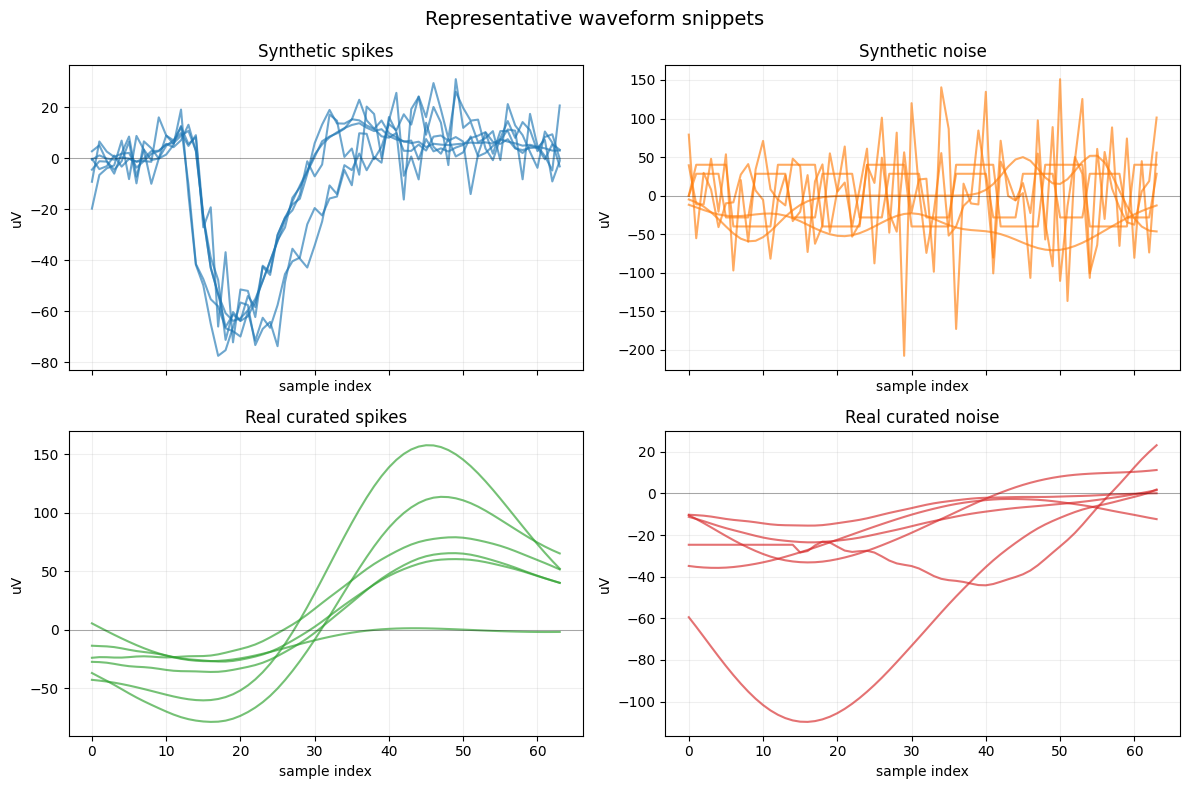

,group,n_waveforms,mean_min_uV,mean_max_uV
0,synthetic_spike,900,-72.798027,24.391356
1,synthetic_noise,300,-79.133217,77.511986
2,real_spike,38145,-37.027191,46.999226
3,real_noise,57861,-32.841469,8.258336


In [7]:
workflow_rows = [
    {
        'step': 'Inspect repo structure',
        'command': 'workspace tree / docs scan',
        'writes_to': 'none',
        'why_it_matters': 'Establishes where data, feature code, notebooks, and APIs live',
    },
    {
        'step': 'Inspect OSort extraction notebook',
        'command': 'notebooks/osort_file_extraction.ipynb',
        'writes_to': 'data/real_units/waveforms_real.npz + metadata',
        'why_it_matters': 'Shows how curated MATLAB spikes become the real benchmark dataset',
    },
    {
        'step': 'Run benchmark on synthetic snippets',
        'command': f"{sys.executable} scripts/run_benchmark.py --tier 2",
        'writes_to': 'data/results/<timestamp>/',
        'why_it_matters': 'Produces feature ranks, model scores, and WeightBank metrics on synthetic data',
    },
    {
        'step': 'Run benchmark on real curated snippets',
        'command': f"{sys.executable} scripts/run_benchmark.py --tier 3 --waveforms-file data/real_units/waveforms_real.npz",
        'writes_to': 'data/results/<timestamp>/',
        'why_it_matters': 'Tests whether benchmarked features transfer to curated human recordings',
    },
]

workflow_df = pd.DataFrame(workflow_rows)
display(workflow_df)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis('off')
tbl = ax.table(
    cellText=workflow_df.values,
    colLabels=workflow_df.columns,
    cellLoc='left',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
plt.show()

## 5. Inspect the latest benchmark run

A run directory is the repo's main **analysis product**.

This section reads the latest run as a set of transparent objects:

- `run_summary.json`
- `weight_bank_metrics.json`
- `single_feature_ranks.parquet`
- `feature_set_ranks.parquet`

The idea is to answer four questions quickly:

1. how many snippets and features were used,
2. how strong the WeightBank was on that run,
3. which single features ranked highest,
4. which feature sets ranked highest.

In [8]:
if LATEST_RUN is None:
    print('No run directory found under data/results/.')
else:
    run_summary = json.loads((LATEST_RUN / 'run_summary.json').read_text()) if (LATEST_RUN / 'run_summary.json').exists() else {}
    wb_metrics = json.loads((LATEST_RUN / 'weight_bank_metrics.json').read_text()) if (LATEST_RUN / 'weight_bank_metrics.json').exists() else {}
    single_feature = pd.read_parquet(LATEST_RUN / 'single_feature_ranks.parquet') if (LATEST_RUN / 'single_feature_ranks.parquet').exists() else pd.DataFrame()
    feature_sets = pd.read_parquet(LATEST_RUN / 'feature_set_ranks.parquet') if (LATEST_RUN / 'feature_set_ranks.parquet').exists() else pd.DataFrame()

    display(Markdown(f"### Latest run: `{LATEST_RUN.name}`"))

    summary_table = pd.DataFrame([
        {'metric': 'n_snippets', 'value': run_summary.get('n_snippets')},
        {'metric': 'n_samples', 'value': run_summary.get('n_samples')},
        {'metric': 'n_features', 'value': run_summary.get('n_features')},
        {'metric': 'n_spikes', 'value': run_summary.get('n_spikes')},
        {'metric': 'n_noise', 'value': run_summary.get('n_noise')},
        {'metric': 'top_feature', 'value': run_summary.get('top_feature')},
        {'metric': 'top_feature_set', 'value': run_summary.get('top_feature_set')},
        {'metric': 'weight_bank_auc', 'value': run_summary.get('weight_bank_auc')},
    ])
    display(summary_table)

    if wb_metrics:
        cm = wb_metrics.get('confusion_matrix', {})
        wb_table = pd.DataFrame([
            {'metric': 'auc', 'value': wb_metrics.get('auc')},
            {'metric': 'balanced_accuracy', 'value': wb_metrics.get('balanced_accuracy')},
            {'metric': 'precision', 'value': cm.get('precision')},
            {'metric': 'recall', 'value': cm.get('recall')},
            {'metric': 'fpr', 'value': cm.get('fpr')},
            {'metric': 'threshold', 'value': wb_metrics.get('threshold')},
            {'metric': 'TP', 'value': cm.get('TP')},
            {'metric': 'FP', 'value': cm.get('FP')},
            {'metric': 'TN', 'value': cm.get('TN')},
            {'metric': 'FN', 'value': cm.get('FN')},
        ])
        display(Markdown('### WeightBank metrics'))
        display(wb_table)

    if not single_feature.empty:
        display(Markdown('### Top single features'))
        keep = [c for c in ['rank', 'feature', 'fisher_score', 'mutual_info', 'auc'] if c in single_feature.columns]
        display(single_feature[keep].sort_values('rank').head(10))

    if not feature_sets.empty:
        display(Markdown('### Top feature sets'))
        keep = [c for c in ['rank', 'set_name', 'model', 'n_features_in_set', 'balanced_acc_mean', 'balanced_acc_std', 'silhouette'] if c in feature_sets.columns]
        display(feature_sets[keep].sort_values('rank').head(10))

### Latest run: `20260405_153115`

,metric,value
0,n_snippets,1200
1,n_samples,64
2,n_features,18
3,n_spikes,900
4,n_noise,300
5,top_feature,ev_baseline_rms
6,top_feature_set,set_A_ultra_fast
7,weight_bank_auc,0.999778


### WeightBank metrics

,metric,value
0,auc,0.999778
1,balanced_accuracy,0.890000
2,precision,0.931677
3,recall,1.000000
4,fpr,0.220000
5,threshold,0.500000
6,TP,900.000000
7,FP,66.000000
8,TN,234.000000
9,FN,0.000000


### Top single features

,rank,feature,fisher_score,mutual_info,auc
0,1,ev_baseline_rms,1.730707,0.410939,0.926259
1,2,ev_absolute_area,1.580901,0.357370,0.931163
2,3,ev_full_width_samples,1.037911,0.303702,0.887993
3,4,peak_amplitude,0.970095,0.338533,0.835889
4,5,ev_peak_amplitude,0.970095,0.338533,0.835889
5,6,max_slope,0.831288,0.283042,0.798863
6,7,ev_max_rising_slope,0.831288,0.283042,0.798863
7,8,min_slope,0.575515,0.349402,0.717911
8,9,ev_max_falling_slope,0.575515,0.349402,0.717911
9,10,max_abs_curvature,0.552812,0.242232,0.689259


### Top feature sets

,rank,set_name,model,n_features_in_set,balanced_acc_mean,balanced_acc_std,silhouette
0,1,set_A_ultra_fast,knn_k5,4.0,0.991667,1.110223e-16,0.576023
1,2,set_C_refined_discrimination,knn_k5,2.0,0.972222,9.296223e-03,0.596895
2,3,set_D_combined,knn_k5,5.0,0.970000,1.247219e-02,0.445814
3,4,set_B_fast_plus_shape,knn_k5,5.0,0.970000,1.247219e-02,0.453380
4,5,set_C_refined_discrimination,logistic_regression,2.0,0.938333,1.715938e-02,0.596895
5,6,set_A_ultra_fast,linear_svm,4.0,0.931111,1.365356e-02,0.576023
6,7,set_A_ultra_fast,logistic_regression,4.0,0.927778,1.448712e-02,0.576023
7,8,set_D_combined,linear_svm,5.0,0.920556,1.726697e-02,0.445814
8,9,set_B_fast_plus_shape,linear_svm,5.0,0.920556,1.726697e-02,0.453380
9,10,set_B_fast_plus_shape,logistic_regression,5.0,0.918333,1.286204e-02,0.453380


## 6. Optional local API probe

This cell stays inert unless `CALL_LOCAL_API = True`.

It is useful when the API is already running and you want a high-level health check without leaving the notebook.

In [9]:
if CALL_LOCAL_API:
    import requests

    base = 'http://127.0.0.1:8099/api'
    dataset = requests.get(f'{base}/ephys/dataset', timeout=10)
    tests = requests.get(f'{base}/ephys/tests', timeout=10)

    print('GET /ephys/dataset ->', dataset.status_code)
    print('GET /ephys/tests   ->', tests.status_code)

    if dataset.ok:
        display(pd.DataFrame([dataset.json()]).T.rename(columns={0: 'value'}))
    if tests.ok:
        tests_json = tests.json()
        if isinstance(tests_json, dict) and 'tests' in tests_json:
            display(pd.DataFrame(tests_json['tests']))
        else:
            display(pd.DataFrame(tests_json))

    if RUN_REAL_EVAL and LATEST_RUN is not None:
        payload = {'run_id': LATEST_RUN.name, 'tier': 2}
        r = requests.post(f'{base}/ephys/evaluate', json=payload, timeout=60)
        print('POST /ephys/evaluate ->', r.status_code)
        if r.ok:
            result = r.json()
            display(Markdown('### Real-data evaluation — overall metrics'))
            display(pd.DataFrame([result.get('overall', {})]).T.rename(columns={0: 'value'}))
            if 'per_su_recall' in result:
                su_df = pd.DataFrame(result['per_su_recall']).T.reset_index().rename(columns={'index': 'unit_id'})
                display(Markdown('### Real-data evaluation — per-SU recall'))
                display(su_df)
else:
    print('API calls skipped. Set CALL_LOCAL_API = True to enable.')

API calls skipped. Set CALL_LOCAL_API = True to enable.


## 7. What this notebook gives you

If the notebook made sense, you now have a compact mental model of the repo:

- **waveforms** live in NPZ bundles,
- **labels / provenance** live in Parquet or CSV tables,
- **analysis outputs** live in timestamped run directories,
- **the API** is an optional read layer over those same objects,
- **the real scientific question** is whether synthetic conclusions survive contact with curated real recordings.

### Suggested next steps

1. Read [docs/ORIENTATION.md](../docs/ORIENTATION.md).
2. Open `notebooks/osort_file_extraction.ipynb` if you want to understand how the real dataset was assembled.
3. Run the pipeline once on synthetic data, then once on `waveforms_real.npz`.
4. Compare the resulting run directories side by side.

A later iteration can add more guard rails, richer widgets, or a tighter SpikeInterface bridge. This first version is intentionally simple and inspectable.